In [1]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import pickle
import numpy as np

path = '/kaggle/input/datasets/valentynsichkar/traffic-signs-preprocessed/'

with open(path + 'data2.pickle', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(data.keys())

dict_keys(['y_test', 'y_validation', 'x_validation', 'x_train', 'y_train', 'labels', 'x_test'])


**Since the description of the dataset mention that it is already preprocessed (data) is already Shuffled, /255.0 + Mean Normalization**

**Also the DataSet is already split into train and test**

In [3]:
X_train, y_train = data['x_train'], data['y_train']
X_valid, y_valid = data['x_validation'], data['y_validation']
X_test, y_test = data['x_test'], data['y_test']
labels = data['labels']

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(86989, 3, 32, 32) (86989,)
(4410, 3, 32, 32) (4410,)
(12630, 3, 32, 32) (12630,)


In [4]:
print("X_train shape:", X_train.shape)
print("X_train dtype:", X_train.dtype)
print("Min:", X_train.min(), "Max:", X_train.max())

X_train shape: (86989, 3, 32, 32)
X_train dtype: float32
Min: -0.37349513 Max: 0.8779018


In [5]:
import pandas as pd
label_names = pd.read_csv('/kaggle/input/datasets/valentynsichkar/traffic-signs-preprocessed/label_names.csv')
label_names.head()

,ClassId,SignName
0,0,Speed limit (20km/h)
1,1,Speed limit (30km/h)
2,2,Speed limit (50km/h)
3,3,Speed limit (60km/h)
4,4,Speed limit (70km/h)


In [6]:
print("Before transpose:", X_train.shape)

if X_train.shape[1] == 3:
    X_train = X_train.transpose(0, 2, 3, 1)
    X_valid = X_valid.transpose(0, 2, 3, 1)
    X_test  = X_test.transpose(0, 2, 3, 1)

print("After transpose:", X_train.shape)  # should now be (N, 32, 32, 3)

Before transpose: (86989, 3, 32, 32)
After transpose: (86989, 32, 32, 3)


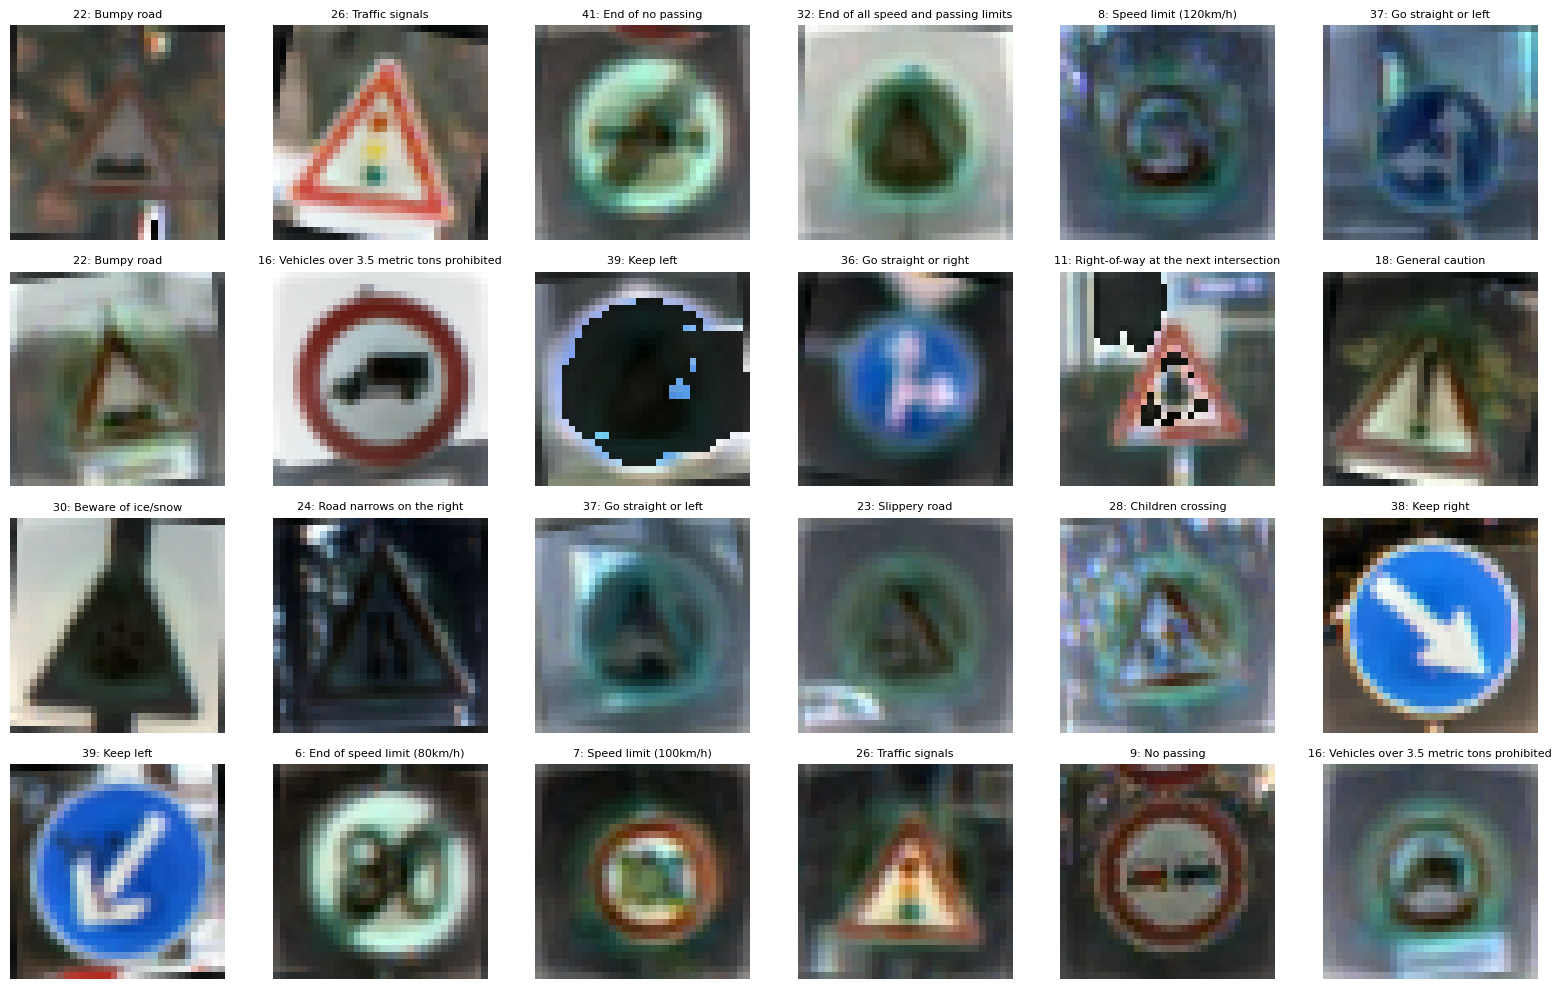

In [7]:
import matplotlib.pyplot as plt

cols = label_names.columns.tolist()
id_col = cols[0]
name_col = cols[1]

fig, axes = plt.subplots(4, 6, figsize=(16, 10))
for ax in axes.flat:
    idx = np.random.randint(0, X_train.shape[0])
    img = X_train[idx]

    # min-max normalize just for display
    img_disp = (img - img.min()) / (img.max() - img.min() + 1e-8)

    class_id = y_train[idx]
    match = label_names[label_names[id_col] == class_id][name_col].values
    class_name = match[0] if len(match) else str(class_id)

    ax.imshow(img_disp)
    ax.set_title(f"{class_id}: {class_name}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
pd.set_option('display.max_rows', None)
print(label_names)

    ClassId                                           SignName
0         0                               Speed limit (20km/h)
1         1                               Speed limit (30km/h)
2         2                               Speed limit (50km/h)
3         3                               Speed limit (60km/h)
4         4                               Speed limit (70km/h)
5         5                               Speed limit (80km/h)
6         6                        End of speed limit (80km/h)
7         7                              Speed limit (100km/h)
8         8                              Speed limit (120km/h)
9         9                                         No passing
10       10       No passing for vehicles over 3.5 metric tons
11       11              Right-of-way at the next intersection
12       12                                      Priority road
13       13                                              Yield
14       14                                            

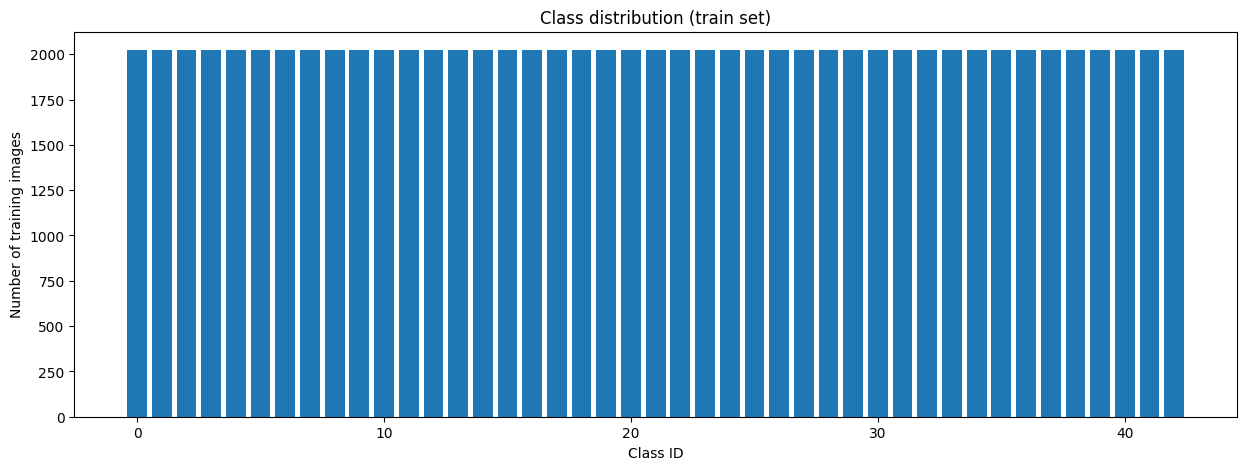

Smallest class has 2023 images | Largest has 2023


In [9]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(15,5))
plt.bar(unique, counts)
plt.xlabel("Class ID")
plt.ylabel("Number of training images")
plt.title("Class distribution (train set)")
plt.show()

print("Smallest class has", counts.min(), "images | Largest has", counts.max())

**the data set is equally distributed , no calss imbalance**

In [10]:
print("X_train range:", X_train.min(), X_train.max())
print("X_valid range:", X_valid.min(), X_valid.max())
print("X_test range:", X_test.min(), X_test.max())

X_train range: -0.37349513 0.8779018
X_valid range: -0.33820102 0.8779018
X_test range: -0.36078945 0.8779018


already standarized

**Model building**

In [11]:
from tensorflow.keras import layers, models, regularizers
num_classes = len(np.unique(y_train))
print("Num classes:", num_classes)

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_valid_cat = tf.keras.utils.to_categorical(y_valid, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)

Num classes: 43


In [12]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),


    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1786913706.918912    1487 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786913706.921172    1487 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 825,419 (3.15 MB)

 Trainable params: 824,011 (3.14 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_valid, y_valid_cat),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  14/1360 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.0313 - loss: 4.9608

I0000 00:00:1786913723.113493    1553 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1360/1360 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.7278 - loss: 1.0405 - val_accuracy: 0.9410 - val_loss: 0.2520 - learning_rate: 0.0010
Epoch 2/30
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9585 - loss: 0.2028 - val_accuracy: 0.9655 - val_loss: 0.1734 - learning_rate: 0.0010
Epoch 3/30
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9735 - loss: 0.1576 - val_accuracy: 0.9746 - val_loss: 0.1645 - learning_rate: 0.0010
Epoch 4/30
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9786 - loss: 0.1446 - val_accuracy: 0.9803 - val_loss: 0.1673 - learning_rate: 0.0010
Epoch 5/30
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9822 - loss: 0.1375 - val_accuracy: 0.9785 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 6/30
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9845 - loss: 0.1328 - val_accuracy: 0.9828 - val_loss: 0.1444 - learning_rate: 0.0010
Epoch 7/30
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9863 - loss

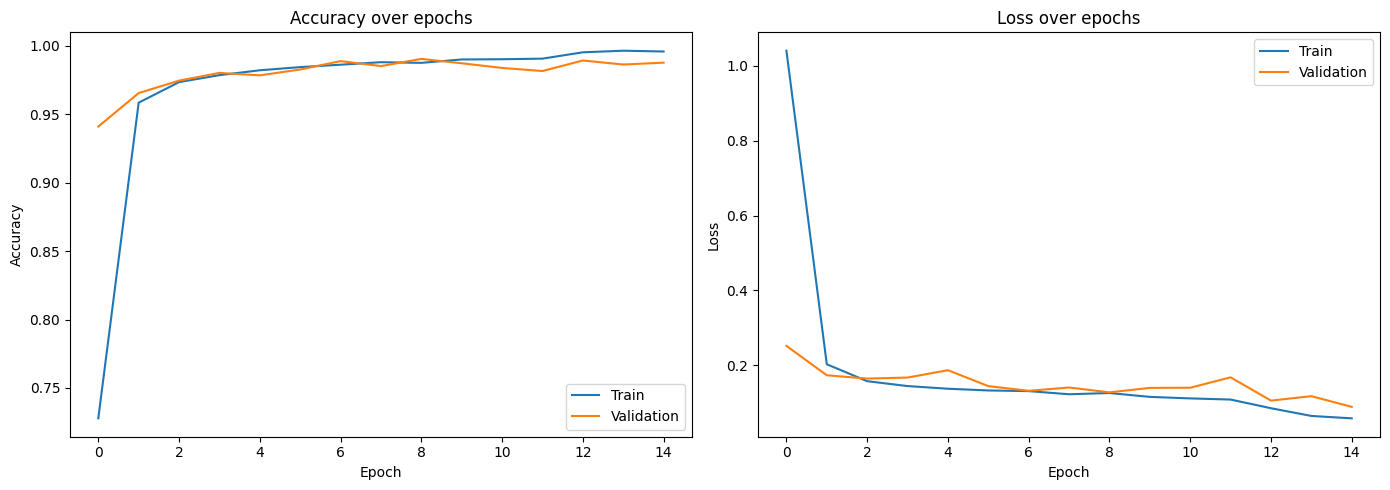

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred)

print("y_pred shape:", y_pred.shape)

print("Confusion matrix shape:", cm.shape)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
y_pred shape: (12630,)
Confusion matrix shape: (43, 43)
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9792 - loss: 0.1539

Test Accuracy: 97.92%
Test Loss: 0.1539


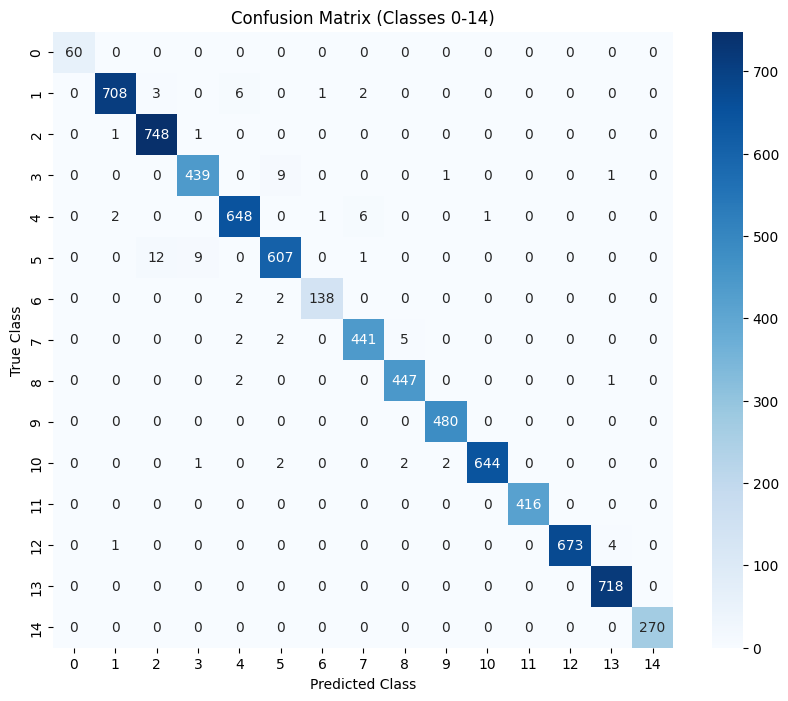

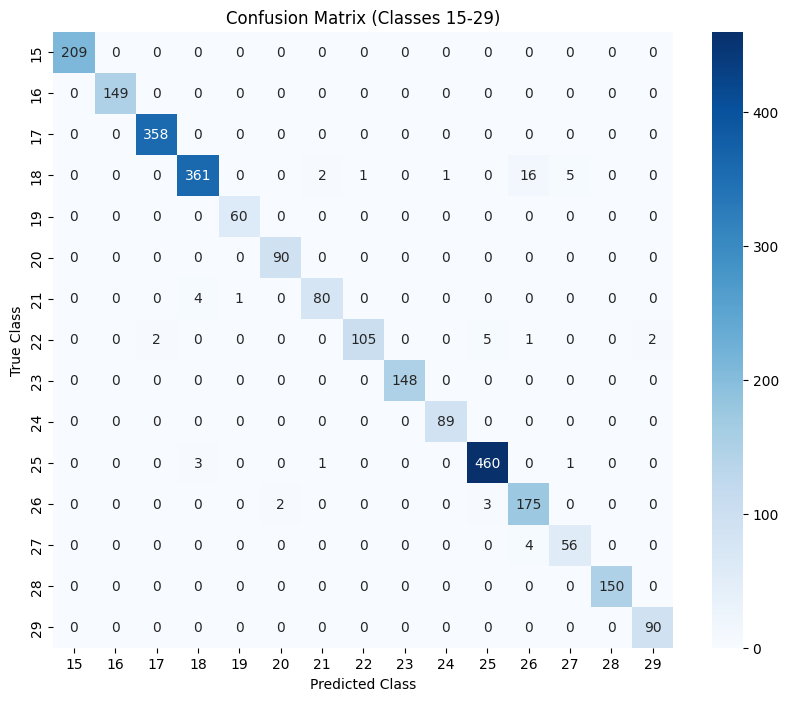

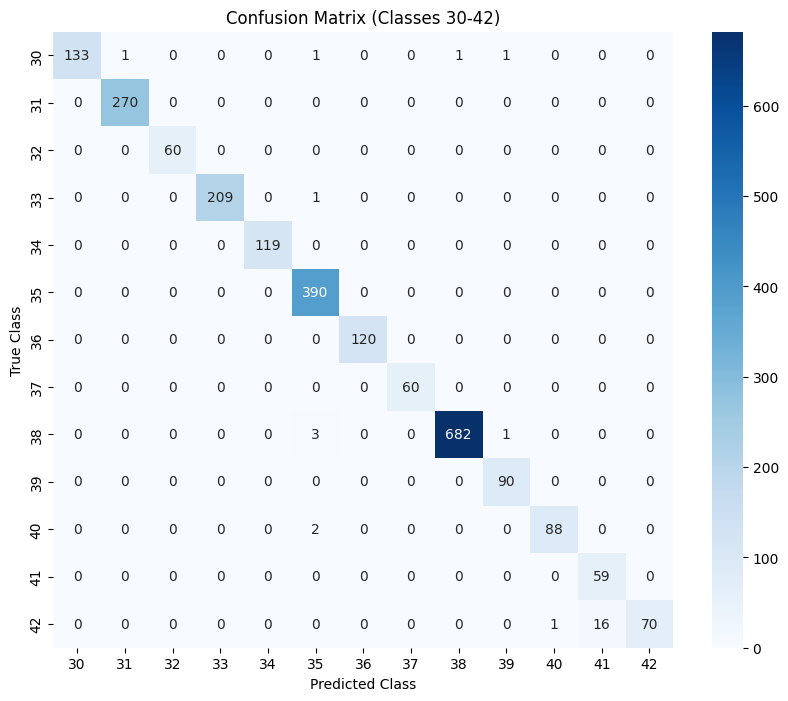

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

n_classes = cm.shape[0]
chunk_size = 15
chunks = [(i, min(i+chunk_size, n_classes)) for i in range(0, n_classes, chunk_size)]

for start, end in chunks:
    plt.figure(figsize=(10,8))
    sns.heatmap(cm[start:end, start:end], annot=True, fmt='d', cmap='Blues',
                xticklabels=range(start,end), yticklabels=range(start,end))
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.title(f'Confusion Matrix (Classes {start}-{end-1})')
    plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.99      0.98      0.99       720
           2       0.98      1.00      0.99       750
           3       0.97      0.98      0.97       450
           4       0.98      0.98      0.98       660
           5       0.98      0.96      0.97       630
           6       0.99      0.92      0.95       150
           7       0.98      0.98      0.98       450
           8       0.98      0.99      0.99       450
           9       0.99      1.00      1.00       480
          10       1.00      0.98      0.99       660
          11       0.95      0.99      0.97       420
          12       1.00      0.98      0.99       690
          13       0.99      1.00      0.99       720
          14       0.99      1.00      0.99       270
          15       1.00      1.00      1.00       210
          16       0.99      0.99      0.99       150
          17       0.99    

Total misclassified: 263 out of 12630


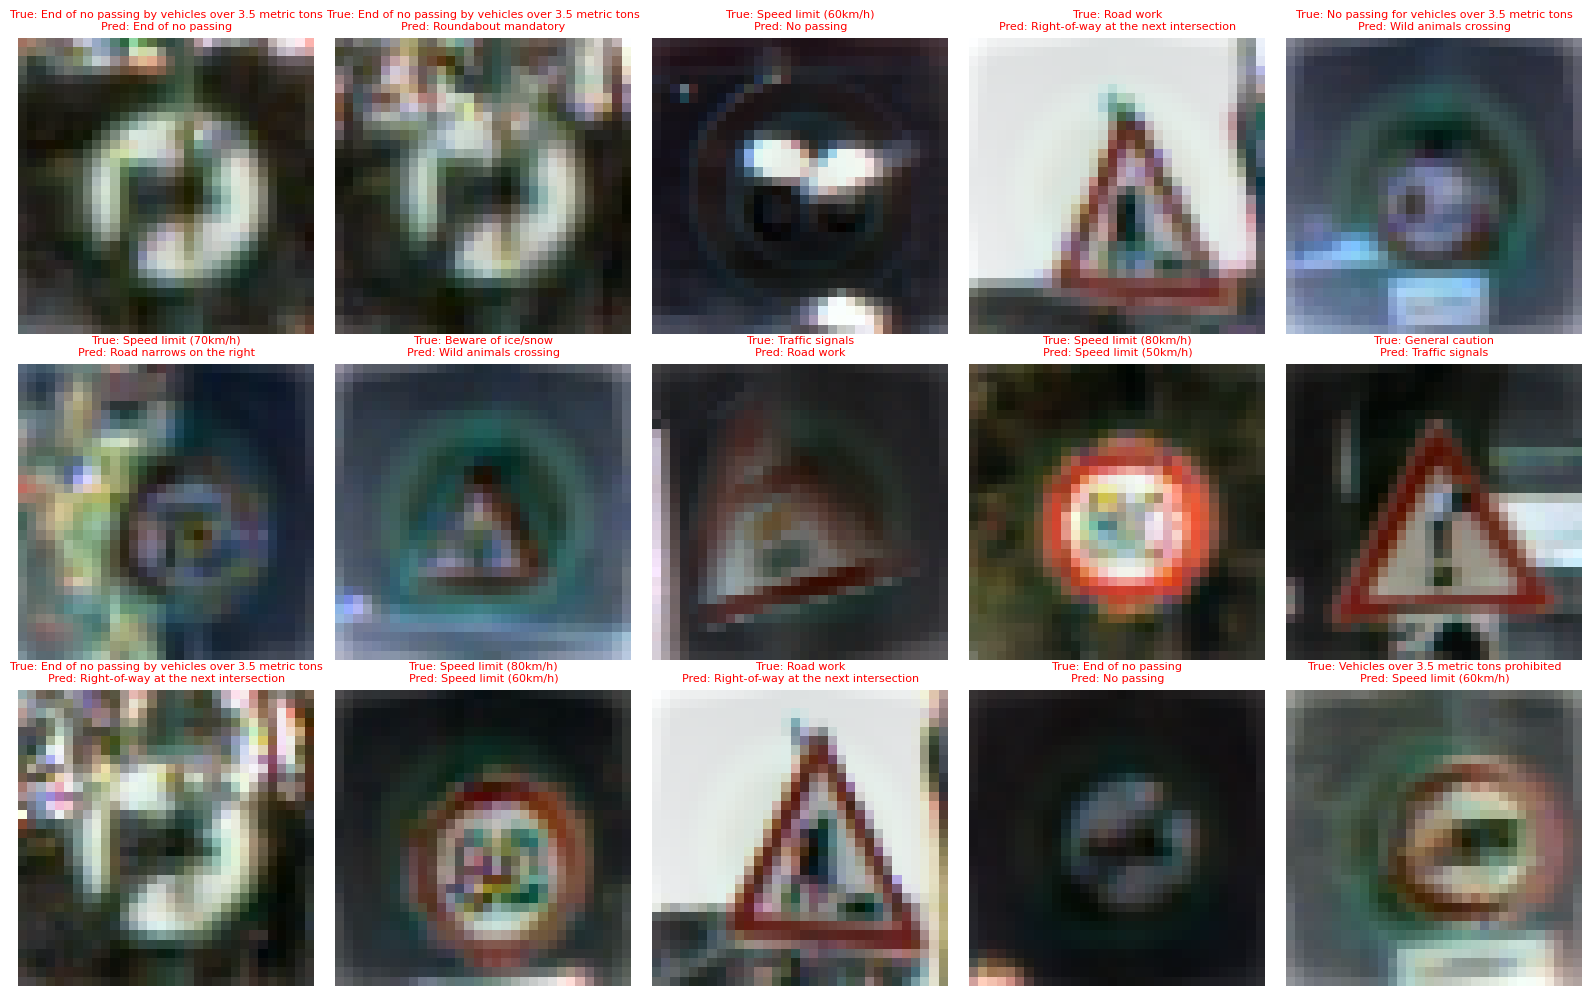

In [19]:
cols = label_names.columns.tolist()
id_col, name_col = cols[0], cols[1]

def get_name(class_id):
    match = label_names[label_names[id_col] == class_id][name_col].values
    return match[0] if len(match) else str(class_id)

# find some misclassified examples
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(y_test)}")

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for ax in axes.flat:
    if len(wrong_idx) == 0:
        break
    idx = np.random.choice(wrong_idx)
    img = X_test[idx]
    img_disp = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    true_name = get_name(y_test[idx])
    pred_name = get_name(y_pred[idx])
    
    ax.imshow(img_disp)
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()